# Image Classification
In this notebook, a simple Image Classification model is implemented, analyzing its performance to use them as a baseline for future analysis on compressed input data

In [ ]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Subset
import os
import matplotlib.pyplot as plt
import torchvision.transforms as transforms # Added import for transforms

# setup the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. The dataset
The CIFAR-10 dataset is a collection of images that are used to train machine learning and computer vision algorithms. It consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

### 1.1 Dataset Download
The dataset has been downloaded on Google Drive, to make the retrieval faster among different sessions

In [3]:
from google.colab import drive

drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/datasets'

# Transformations
transform = transforms.Compose([
    transforms.Resize(224), # Resize images to 224x224 for ResNet50, using bilinear interpolation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize for pre-trained ImageNet models
])

# Upload the training set from Drive. Set download=False
train_data = datasets.CIFAR10(
    root=data_dir,
    train=True,
    download=False,
    transform=transform
)

# Upload the test set from Drive. Set download=False
test_data = datasets.CIFAR10(
    root=data_dir,
    train=False,
    download=False,
    transform=transform
)

# Print size
n_train_data = len(train_data)
n_test_data = len(test_data)
print(f"Training data: {n_train_data} samples")
print(f"Test data: {n_test_data} samples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training data: 50000 samples
Test data: 10000 samples


OSS:
- `train_data` is an object containing all the image tensors and their respective labels
- `train_data[k]` is an object containing an image tensor and its label
- `train_data[k][0]` is the tensor
- `train_data[k][1]` is the label

### 1.2 (optional) Subset generation
In a first exploratory phase, using a subset of the whole dataset could be useful to make the computation faster, and check quickier if the implementation works (no code errors, at least)

In [12]:
# For instance: 10% of training set and 10% of test set
p = 0.1

num_train_samples = int(n_train_data * p)
num_test_samples = int(n_test_data * p)

# Pick random elements
train_indices = torch.randperm(len(train_data))[:num_train_samples]
train_subset = Subset(train_data, train_indices)

test_indices = torch.randperm(len(test_data))[:num_test_samples]
test_subset = Subset(test_data, test_indices)

print(f"Training subset: {len(train_subset)} samples")
print(f"Test subset: {len(test_subset)} samples")

# Show the size of an image and its class label
print(f"Image size: {train_subset[0][0].shape}\nImage class: {train_subset[0][1]}")

Training subset: 5000 samples
Test subset: 1000 samples
Image size: torch.Size([3, 224, 224])
Image class: 3


#2. Batches generation and dataset visualization

DataLoaders dimensions:
Length of train dataloader: 1563 batches of 32
Length of test dataloader: 313 batches of 32

Batch content:
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])



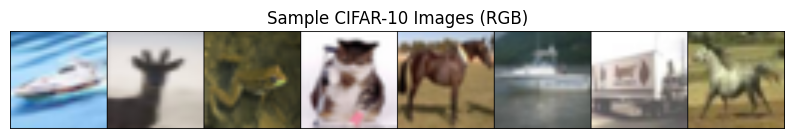

In [18]:
from torch.utils.data import DataLoader
import numpy as np

BATCH_SIZE = 32 # hyperparameter

# Create DataLoaders for training and testing data
# Using train_subset and test_subset for faster computation
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True # to shuffle the data at each epoch
                              )

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

# print the dimensions of the DataLoaders
print("DataLoaders dimensions:")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}\n")

# show a single batch
train_features_batch, train_labels_batch = next(iter(train_dataloader))
print("Batch content:")
print(f"Images: {train_features_batch.shape}\nLabels: {train_labels_batch.shape}\n")

# show images in a batch (RGB visualization)
# Take a batch of images and labels
x, y = next(iter(train_dataloader))

# Denormalize the images for correct visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
x_denormalized = x * std + mean

# Create a grid of images from the first 8 samples (or more if desired)
grid_img = torchvision.utils.make_grid(x_denormalized[:8]) # Select first 8 images

# Permute the dimensions from (C, H, W) to (H, W, C) for matplotlib
plt.figure(figsize=(10, 10)) # Increased figure size
plt.imshow(grid_img.permute(1, 2, 0))

plt.title('Sample CIFAR-10 Images (RGB)')
plt.axis('off')
plt.show()

Show a single image with its associated label

Image shape: torch.Size([3, 224, 224])


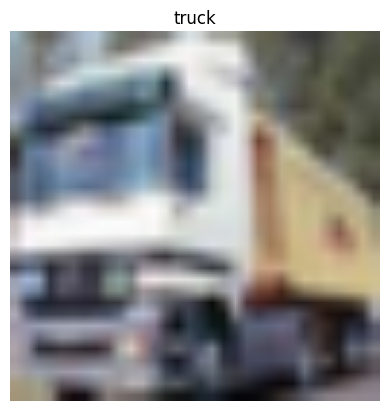

In [19]:
image, label = train_data[1]
print(f"Image shape: {image.shape}")

# Denormalize the image for correct visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
image_denormalized = image * std + mean

# Ensure pixel values are within [0, 1] range after denormalization for display
image_denormalized = torch.clamp(image_denormalized, 0, 1)

plt.imshow(image_denormalized.permute(1, 2, 0)) # permute is necessary to provide a (H, W, C) object to plot

# plot the class name instead of the number of the class
class_names = train_data.classes
plt.title(class_names[label])
plt.axis('off')
plt.show()

#3. The Model: Pre-Trained ResNet50
In a first try, the ResNet50 model is used. At first, only a fine tuning of the last layer, for make the size compatible, is made

In [21]:
import torchvision.models as models

# Load a pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters in the network
# We will unfreeze the final layer later
for param in model.parameters():
    param.requires_grad = False

# Modify the last fully connected (fc) layer for CIFAR-10 (10 classes)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(in_features=num_ftrs, out_features=10) # CIFAR-10 has 10 classes

# Move the model to the appropriate device (CPU or GPU)
model = model.to(device)

print("ResNet50 model loaded and configured for CIFAR-10 transfer learning:")
print(model)
print("\nNumber of output features in the final layer:", model.fc.out_features)

ResNet50 model loaded and configured for CIFAR-10 transfer learning:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Seq

In [28]:
# Print a summary using torchinfo (uncomment for actual output)
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

summary(model=model,
        input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=15,
        row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape     Output Shape    Param #         Trainable
ResNet (ResNet)                          [32, 3, 224, 224] [32, 10]        --              Partial
├─Conv2d (conv1)                         [32, 3, 224, 224] [32, 64, 112, 112] (9,408)         False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112] [32, 64, 112, 112] (128)           False
├─ReLU (relu)                            [32, 64, 112, 112] [32, 64, 112, 112] --              --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112] [32, 64, 56, 56] --              --
├─Sequential (layer1)                    [32, 64, 56, 56] [32, 256, 56, 56] --              False
│    └─Bottleneck (0)                    [32, 64, 56, 56] [32, 256, 56, 56] --              False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56] [32, 64, 56, 56] (4,096)         False
│    │    └─BatchNorm2d (bn1)            [32, 64, 56, 56] [32, 64, 56, 56] (128)           False
│    │    └─ReLU 

#4. Functions
Some functions helpful for repeated workflows

### 4.1 Training and testing

In [30]:
# training phase
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.to(device)

  for batch, (x,y) in enumerate(data_loader): # Wrap data_loader with tqdm

    x = x.to(device)
    y = y.to(device)

    # feed-forward
    y_logit = model(x)
    y_pred = y_logit.argmax(dim=1)

    # loss evaluation (and accuracy)
    loss = loss_fn(y_logit, y) # as loss we use nn.CrossEntropyLoss(), so it requires the logits as input
    train_loss += loss
    train_acc += accuracy_fn(y, y_pred) # accuracy function requires as input the prediction already transformed into probabilities

    # set to zero the gradients (if not, they would be accumulated)
    optimizer.zero_grad()

    # backpropagation (=compute gradients)
    loss.backward()

    # update the parameters
    optimizer.step()


  # compute avg loss and avg accuracy per each epoch
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")



# test phase
def test_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for x,y in data_loader: # Wrap data_loader with tqdm

      # send data to the GPU
      x = x.to(device)
      y = y.to(device)

      # feed-forward
      test_logit = model(x)
      test_pred = test_logit.argmax(dim=1)

      # loss evaluation (and accuracy)
      test_loss += loss_fn(test_logit, y) # as loss we use nn.CrossEntropyLoss(), so it requires the logits as input
      test_acc += accuracy_fn(y, test_pred) # accuracy function requires as input the prediction already transformed into probabilities


    # compute avg loss and avg accuracy per each epoch
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

### 4.2 Timing function

In [31]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    # device ([type], optional): Device that compute is running on. Defaults to None.

    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### 4.3 Accuracy Function


In [39]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#5. Training and Test loops


In [34]:
# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),
                             lr=0.1)

In [38]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"\nEpoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model = timer()
total_train_time_model = print_train_time(start=train_time_start_model,
                                           end=train_time_end_model,
                                           device=device)

  0%|          | 0/5 [00:00<?, ?it/s]


Epoch: 0
---------
Train loss: 0.82274 | Train accuracy: 77.22%
Test loss: 2.19938 | Test accuracy: 61.90%

Epoch: 1
---------
Train loss: 0.78053 | Train accuracy: 78.32%
Test loss: 1.58713 | Test accuracy: 65.46%

Epoch: 2
---------
Train loss: 0.71605 | Train accuracy: 79.50%
Test loss: 1.11558 | Test accuracy: 71.01%

Epoch: 3
---------
Train loss: 0.69994 | Train accuracy: 79.83%
Test loss: 1.03465 | Test accuracy: 72.63%

Epoch: 4
---------
Train loss: 0.68728 | Train accuracy: 80.12%
Test loss: 2.24513 | Test accuracy: 67.51%
Train time on cuda: 1343.212 seconds


#6. Save and load the model
What we save of a model are its parameters so when we load it back we should create an instance of the model, then set as parameter values, the values we saved

In [ ]:
from pathlib import Path

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                 exist_ok=True # if models directory already exists, don't error
)

# Create model save path
MODEL_NAME = "ResNet50.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/ResNet50.pth


### Loading the saved model

In [ ]:
import torchvision.models as models

# 1. Instantiate a new model with the same architecture
# It's important to create the model with the same setup as when it was saved
loaded_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all parameters initially, just like the original model setup
for param in loaded_model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer for CIFAR-10 (10 classes)
num_ftrs_loaded = loaded_model.fc.in_features
loaded_model.fc = nn.Linear(in_features=num_ftrs_loaded, out_features=10)

# 2. Load the saved state_dict
# Make sure to map to the correct device, especially if you saved on GPU and are loading on CPU or vice-versa
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

# 3. Move the loaded model to the target device
loaded_model = loaded_model.to(device)

print("Model loaded successfully!")

# You can verify that the model's parameters are loaded by comparing them or by running an inference step
# For example, let's print the first few parameters of the loaded model's final layer
print("\nFirst 5 weights of the loaded model's final layer:")
print(loaded_model.fc.weight[:5])

Model loaded successfully!

First 5 weights of the loaded model's final layer:
tensor([[ 0.0039,  0.0064,  0.0007,  ...,  0.0151, -0.1723, -0.0374],
        [-0.0221, -0.0318, -0.0880,  ...,  0.0708,  0.0909,  0.0105],
        [ 0.0470,  0.0915,  0.0632,  ...,  0.0334,  0.0020,  0.0085],
        [ 0.0047, -0.0318,  0.0040,  ...,  0.0897, -0.0164, -0.0055],
        [-0.0554, -0.0444,  0.0104,  ..., -0.0445,  0.0029, -0.0777]],
       device='cuda:0', grad_fn=<SliceBackward0>)


### Saving the model to Google Drive

In [ ]:
import shutil

# Define the target directory on Google Drive
# Re-using 'data_dir' and creating a 'models' subdirectory within it
data_dir = '/content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/'
drive_models_dir = Path(data_dir) / "models"
drive_models_dir.mkdir(parents=True, exist_ok=True)

# Define the full path for saving the model on Google Drive
MODEL_SAVE_PATH_DRIVE = drive_models_dir / MODEL_NAME

# Copy the locally saved model to Google Drive
shutil.copy(MODEL_SAVE_PATH, MODEL_SAVE_PATH_DRIVE)

print(f"Model saved to Google Drive at: {MODEL_SAVE_PATH_DRIVE}")

Model saved to Google Drive at: /content/drive/MyDrive/Colab Notebooks/AARHUS INTERNSHIP/models/ResNet50.pth
